## Task 1 —> Data Profiling & Duplicate Detection

1. The number of rows and columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("MoviesOnStreamingPlatforms.csv")

print("Shape:", df.shape)
df.head()

Shape: (9515, 11)


,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


2. Shows column names, data types, and non-null counts all at once

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       9515 non-null   int64 
 1   ID               9515 non-null   int64 
 2   Title            9515 non-null   object
 3   Year             9515 non-null   int64 
 4   Age              5338 non-null   object
 5   Rotten Tomatoes  9508 non-null   object
 6   Netflix          9515 non-null   int64 
 7   Hulu             9515 non-null   int64 
 8   Prime Video      9515 non-null   int64 
 9   Disney+          9515 non-null   int64 
 10  Type             9515 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 817.8+ KB


3. Find duplicates: .duplicate(): checks every row against every other row — returns True if a row is a complete, identical copy of an earlier one (every single column matches). .sum(): just counts how many Trues there are, since True counts as 1 in Python.

In [3]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


4. Check duplicate movies: Find duplicates -->  same movies by title + year

In [4]:
movie_duplicates = df.duplicated(
    subset=["Title", "Year"]
).sum()

print("Duplicate movies:", movie_duplicates)

Duplicate movies: 0


5. Remove unnecessary column --> Unnamed: 0 is basically an old DataFrame index.

In [5]:
df = df.drop(columns=["Unnamed: 0"])
print(df.shape)

(9515, 10)


## Task 2 — Missing Values & Imputation

6. Create missing-value report --> df.isnull() --> turns every cell into True/False (True = missing). .sum() per column counts how many Trues (missing values) each column has.

In [6]:
missing_count = df.isnull().sum()

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent.round(2)
})

missing_report = missing_report[
    missing_report["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)

print(missing_report)

                 Missing Count  Missing %
Age                       4177      43.90
Rotten Tomatoes              7       0.07


## Task 3 —> Data Cleaning

7. Convert Rotten Tomatoes to numbers

In [13]:
df["Rotten Tomatoes"] = pd.to_numeric(
    df["Rotten Tomatoes"]
    .astype("string")
    .str.replace("/100", "", regex=False),
    errors="coerce"
)

print(df["Rotten Tomatoes"].dtype)

Float64


8. Reprenstation of the rotten tomato rating according to the movies: 

In [14]:
df["Rotten Tomatoes"] = pd.to_numeric(
    df["Rotten Tomatoes"],
    errors="coerce"
) / 10

df["Rotten Tomatoes"] = df["Rotten Tomatoes"].round(1)

print(df[["Title", "Rotten Tomatoes"]].head(10))

                                      Title  Rotten Tomatoes
0                              The Irishman              9.8
1                                    Dangal              9.7
2  David Attenborough: A Life on Our Planet              9.5
3         Lagaan: Once Upon a Time in India              9.4
4                                      Roma              9.4
5         To All the Boys I've Loved Before              9.4
6                        The Social Dilemma              9.3
7                                      Okja              9.2
8              The Ballad of Buster Scruggs              9.2
9                The Trial of the Chicago 7              9.2


## Task 4 — Statistical Analysis

9. Descriptive statistics

In [15]:
df.describe()

,ID,Year,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
count,9515.000000,9515.000000,9508.0,9515.000000,9515.000000,9515.000000,9515.000000,9515.0
mean,4758.000000,2007.422386,5.354501,0.388334,0.110037,0.432265,0.096900,0.0
std,2746.888239,19.130367,1.319767,0.487397,0.312952,0.495417,0.295837,0.0
min,1.000000,1914.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.0
25%,2379.500000,2006.000000,4.4,0.000000,0.000000,0.000000,0.000000,0.0
50%,4758.000000,2015.000000,5.2,0.000000,0.000000,0.000000,0.000000,0.0
75%,7136.500000,2018.000000,6.2,1.000000,0.000000,1.000000,0.000000,0.0
max,9515.000000,2021.000000,9.8,1.000000,1.000000,1.000000,1.000000,0.0


10. For example, for Year and Rotten Tomatoes:

In [16]:
print("Average release year:",
      df["Year"].mean())

print("Average Rotten Tomatoes score:",
      df["Rotten Tomatoes"].mean())

print("Median Rotten Tomatoes score:",
      df["Rotten Tomatoes"].median())

Average release year: 2007.4223857067789
Average Rotten Tomatoes score: 5.354501472444257
Median Rotten Tomatoes score: 5.2


## Task 5 — Analyze Streaming Platforms

11. Count movies available on each platform

In [17]:
platforms = [
    "Netflix",
    "Hulu",
    "Prime Video",
    "Disney+"
]

platform_counts = df[platforms].sum()

print(platform_counts)

Netflix        3695
Hulu           1047
Prime Video    4113
Disney+         922
dtype: int64


## Task 6 — Visualization

12. Movies by streaming platform: This gives you a simple bar graph telling that how many movies are there in each OTT Platform

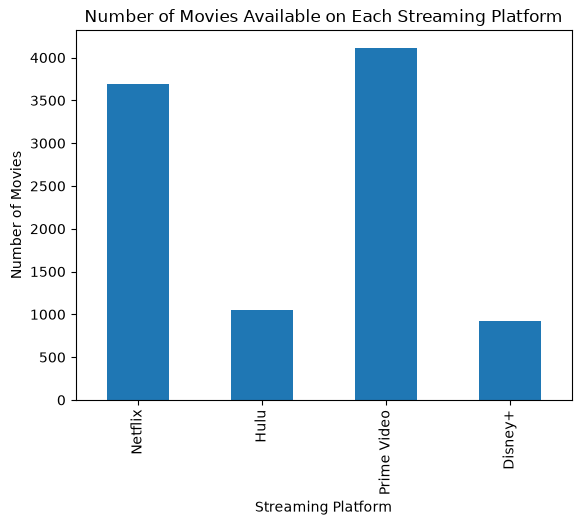

In [18]:
platform_counts.plot(kind="bar")

plt.title("Number of Movies Available on Each Streaming Platform")
plt.xlabel("Streaming Platform")
plt.ylabel("Number of Movies")

plt.show()

13. Movies released by year: This shows how the number of movies changes over the years.

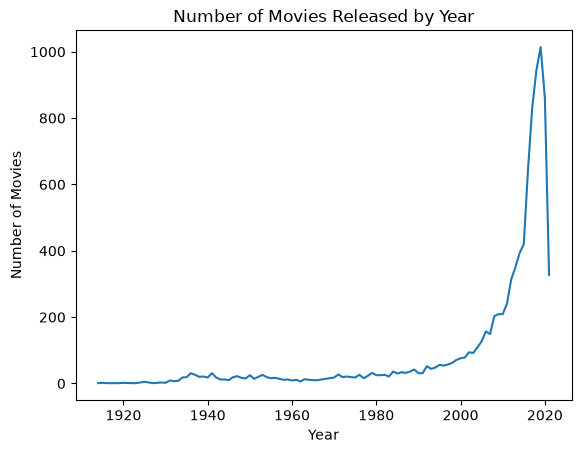

In [19]:
year_counts = df["Year"].value_counts().sort_index()

year_counts.plot(kind="line")

plt.title("Number of Movies Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

14. Rotten Tomatoes distribution: This is a good example of analyzing a numerical variable. It analyzes the rotten tomato distribution of each movies 

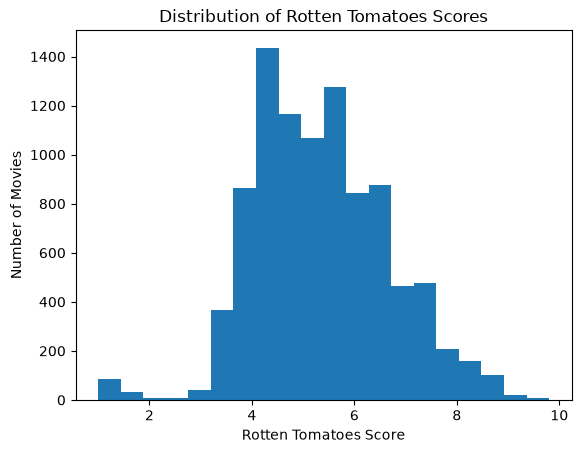

In [20]:
df["Rotten Tomatoes"].plot(
    kind="hist",
    bins=20
)

plt.title("Distribution of Rotten Tomatoes Scores")
plt.xlabel("Rotten Tomatoes Score")
plt.ylabel("Number of Movies")

plt.show()

## Task 7 — Age Rating Analysis

15. Movies by age rating 

Age
18+    2276
7+     1090
13+     998
all     698
16+     276
Name: count, dtype: int64


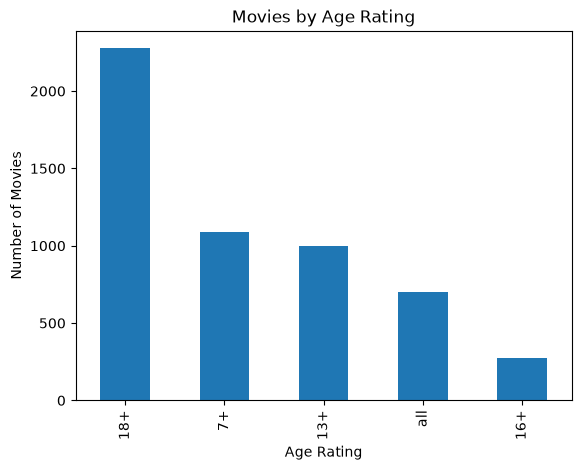

In [21]:
print(df["Age"].value_counts())

df["Age"].value_counts().plot(kind="bar")

plt.title("Movies by Age Rating")
plt.xlabel("Age Rating")
plt.ylabel("Number of Movies")

plt.show()

## Task 8 — Platform Comparison

16. Comparion each platforms by the movie count

Netflix        3695
Hulu           1047
Prime Video    4113
Disney+         922
dtype: int64


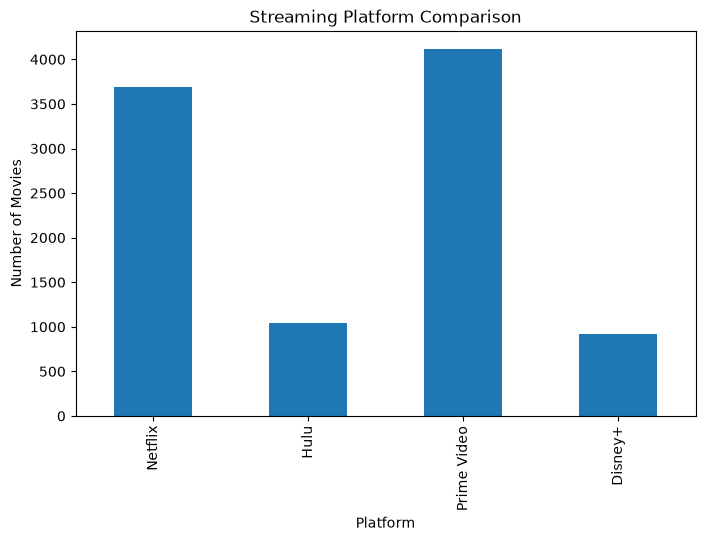

In [22]:
platform_counts = df[
    ["Netflix", "Hulu", "Prime Video", "Disney+"]
].sum()

print(platform_counts)

plt.figure(figsize=(8,5))

platform_counts.plot(kind="bar")

plt.title("Streaming Platform Comparison")
plt.xlabel("Platform")
plt.ylabel("Number of Movies")

plt.show()

## Task 9 — Find highly rated movies

17. This will help in finding high rated movies according to their rotten tomatos: Basically it will sort the rotten tomatoes in the acending order.

In [25]:
top_movies = df.sort_values(
    "Rotten Tomatoes",
    ascending=False
)

print(
    top_movies[
        ["Title", "Year", "Rotten Tomatoes"]
    ].head(10)
)

                                         Title  Year  Rotten Tomatoes
0                                 The Irishman  2019              9.8
1                                       Dangal  2016              9.7
8615                              Mary Poppins  1964              9.6
2     David Attenborough: A Life on Our Planet  2020              9.5
5            To All the Boys I've Loved Before  2018              9.4
3695                           The Dark Knight  2008              9.4
4                                         Roma  2018              9.4
3            Lagaan: Once Upon a Time in India  2001              9.4
4704                                   Tumbbad  2018              9.3
4703                                Fight Club  1999              9.3


## Task 10 — Platform availability of highly rated movies

18. How many highly rated movies are available on each streaming platform?

In [27]:
high_rated = df[
    df["Rotten Tomatoes"] >= 8.0
]

print("Highly rated movies:", len(high_rated))

print(
    high_rated[
        ["Netflix", "Hulu", "Prime Video", "Disney+"]
    ].sum()
)

Highly rated movies: 335
Netflix        168
Hulu            49
Prime Video     53
Disney+         75
dtype: int64


19. This graph directly supports your conclusion: how many movies rated 8.0+ are available on each platform.

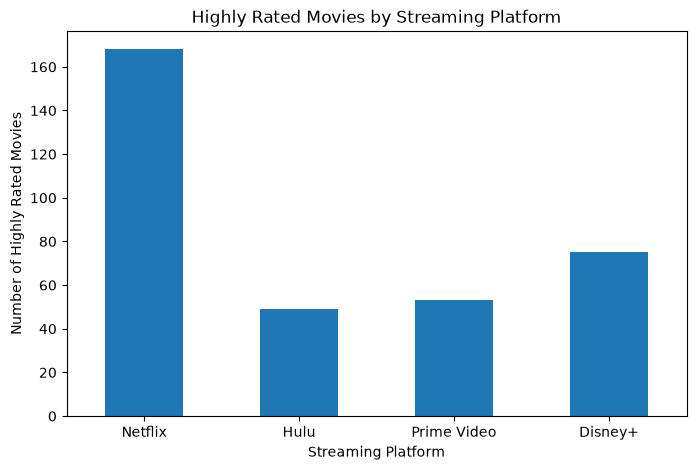

In [28]:
platform_counts = high_rated[
    ["Netflix", "Hulu", "Prime Video", "Disney+"]
].sum()

plt.figure(figsize=(8, 5))

platform_counts.plot(kind="bar")

plt.title("Highly Rated Movies by Streaming Platform")
plt.xlabel("Streaming Platform")
plt.ylabel("Number of Highly Rated Movies")
plt.xticks(rotation=0)

plt.show()

## Conclusion

Conclusion:

In this assignment, the Movies on Streaming Platforms dataset was successfully analyzed using Python and Pandas. The dataset was first explored to understand its structure, columns, data types, and statistical properties. Duplicate records and missing values were identified, and unnecessary columns were removed during data cleaning.

The Rotten Tomatoes ratings were converted from percentage format to a 10-point scale for easier analysis. Statistical analysis and visualizations were then used to understand movie releases, ratings, age classifications, and streaming platform availability.

The analysis also identified highly rated movies with a Rotten Tomatoes score of 8.0 or above and compared their availability across Netflix, Hulu, Prime Video, and Disney+. Bar charts and other visualizations helped present the findings clearly.

Overall, this assignment provided practical experience in data loading, data cleaning, missing-value analysis, statistical analysis, and data visualization using Python.